In [1]:
import platform
platform.platform()

'macOS-26.2-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import os
sys.path.append(os.path.abspath("../.."))

In [4]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [5]:
import matplotlib.pyplot as plt

In [6]:
import pandas as pd
pd.__version__

'2.3.3'

In [7]:
from SSMetrics import metrics

In [8]:
df1 = pd.read_csv("../../1_dataset/1_28descriptors/1_dataset/2_standardization/standardized_dataset.csv")
df1.shape

(4665, 37)

In [9]:
df1.columns

Index(['SMILES', 'InChI', 'InChIKey', 'K3FeCN6', 'MesAcr+BF4-', 'CuCl',
       'Diacetyl', 'T(p-OMe)PPCo', 'Electrode', 'm_1_L', 'm_1_B1', 'm_1_B5',
       'p_L', 'p_B1', 'p_B5', 'm_2_L', 'm_2_B1', 'm_2_B5', 'o_L', 'o_B1',
       'o_B5', 'Charge_O', 'Charge_next_O', 'Charge_o_1', 'Charge_m_1',
       'Charge_p', 'Charge_m_2', 'Charge_o_2', 'HOMO', 'MolLogP', 'MolWt',
       'num_N', 'num_O', 'num_S', 'num_F', 'num_Cl', 'num_Br'],
      dtype='object')

In [10]:
conditions = [["K3FeCN6", "K$_3$[Fe(CN)$_6$]"],
              ["MesAcr+BF4-", "MesAcr$^+$BF$_4^-$"],
              ["CuCl", "CuCl"],
              ["Diacetyl", "Diacetyl"],
              ["T(p-OMe)PPCo", "T($p$-OMe)PPCo"],
              ["Electrode", "Electrode"]]

In [11]:
li_numbers = []
li_range = []
li_details = []

In [12]:
for i in range(6):
    condition = conditions[i][0]
    
    print(f"\n{condition}")
    df2 = df1[df1[condition] == 1]

    n = len(df2)
    li_numbers.append(n)

    ss = metrics.metrics_range(df2)
    li_range.append(ss[0])
    li_details.append(ss[1])
    
    ss[1].to_csv(f"{condition}.csv")


K3FeCN6
Substrate count: 23
Range: 36.22832911362168
                    min       max        Q1        Q2        Q3           std  \
m_1_L         -0.289985 -0.289985 -0.289985 -0.289985 -0.289985  1.699675e-16   
m_1_B1        -0.341846 -0.341846 -0.341846 -0.341846 -0.341846  5.665583e-17   
m_1_B5        -0.284520 -0.284520 -0.284520 -0.284520 -0.284520  1.133117e-16   
p_L           -0.467259  1.687843 -0.159876 -0.071076  0.249970  6.021235e-01   
p_B1          -0.661208  3.092226 -0.360006  0.242397  0.288735  9.239284e-01   
p_B5          -0.504342  1.262730 -0.202302 -0.176897  0.209826  4.955720e-01   
m_2_L         -0.306963 -0.306963 -0.306963 -0.306963 -0.306963  1.133117e-16   
m_2_B1        -0.349180 -0.349180 -0.349180 -0.349180 -0.349180  5.665583e-17   
m_2_B5        -0.311916 -0.311916 -0.311916 -0.311916 -0.311916  0.000000e+00   
o_L           -0.833105  0.119339 -0.833105 -0.222564 -0.159766  3.451783e-01   
o_B1          -1.006215  3.680445 -1.006215 -0.264823  

In [13]:
labels = []

for i in range(6):
    labels.append(f"{conditions[i][1]} ({li_numbers[i]})")
    
labels

['K$_3$[Fe(CN)$_6$] (23)',
 'MesAcr$^+$BF$_4^-$ (20)',
 'CuCl (19)',
 'Diacetyl (12)',
 'T($p$-OMe)PPCo (9)',
 'Electrode (9)']

In [14]:
li_details_2 = []
for i in range(6):
    li_details_2.append(li_details[i]["range"])

In [15]:
df_details = pd.concat(li_details_2, axis=1)
df_details = df_details.set_axis([e[0] for e in conditions], axis=1, copy=False)
df_details

,K3FeCN6,MesAcr+BF4-,CuCl,Diacetyl,T(p-OMe)PPCo,Electrode
m_1_L,0.000000,0.733996,0.000000,0.733996,0.000000,1.424817
m_1_B1,0.000000,2.178914,0.000000,2.178914,0.000000,3.980709
m_1_B5,0.000000,0.680165,0.000000,0.680165,0.000000,0.627337
p_L,2.155103,1.799904,1.885288,0.396184,0.553291,0.368861
p_B1,3.753434,2.896168,5.931353,3.452233,3.452233,2.896168
p_B5,1.767071,1.911034,1.191221,0.327445,1.388817,0.327445
m_2_L,0.000000,0.584547,0.000000,0.000000,0.000000,0.000000
m_2_B1,0.000000,1.969954,0.000000,0.000000,0.000000,0.000000
m_2_B5,0.000000,0.527255,0.000000,0.000000,0.000000,0.000000
o_L,0.952444,2.208413,0.966399,1.915354,0.673339,0.784981


In [16]:
df_details.to_csv("range_details.csv")

In [17]:
orange1 = (246/255, 170/255, 0/255, 0.2)
orange2 = (246/255, 170/255, 0/255, 0.6)
orange3 = (246/255, 170/255, 0/255)

green1 = (3/255, 175/255, 122/255, 0.2)
green2 = (3/255, 175/255, 122/255, 0.6)
green3 = (3/255, 175/255, 122/255)

purple1 = (153/255, 0/255, 153/255, 0.2)
purple2 = (153/255, 0/255, 153/255, 0.6)
purple3 = (153/255, 0/255, 153/255)

sky1 = (77/255, 196/255, 255/255, 0.2)
sky2 = (77/255, 196/255, 255/255, 0.6)
sky3 = (77/255, 196/255, 255/255)

red1 = (255/255, 75/255, 0/255, 0.1)
red2 = (255/255, 75/255, 0/255, 0.25)
red3 = (255/255, 75/255, 0/255, 0.4)
red4 = (255/255, 75/255, 0/255, 0.55)
red5 = (255/255, 75/255, 0/255, 0.7)
red6 = (255/255, 75/255, 0/255, 0.85)
red7 = (255/255, 75/255, 0/255)

blue1 = (0/255, 90/255, 255/255, 0.2)
blue2 = (0/255, 90/255, 255/255, 0.6)
blue3 = (0/255, 90/255, 255/255)

pink1 = (255/255, 128/255, 130/255, 0.2)
pink2 = (255/255, 128/255, 130/255, 0.6)
pink3 = (255/255, 128/255, 130/255)

brown1 = (128/255, 64/255, 0/255, 0.2)
brown2 = (128/255, 64/255, 0/255, 0.6)
brown3 = (128/255, 64/255, 0/255)

In [18]:
colours = [orange1, orange2, orange3,
           green1, green2, green3,
           purple1, purple2, purple3,
           sky1, sky2, sky3,
           red1, red2, red3, red4, red5, red6, red7,
           blue1, blue2, blue3,
           pink1, pink2, pink3, brown1, brown2, brown3]
len(colours)

28

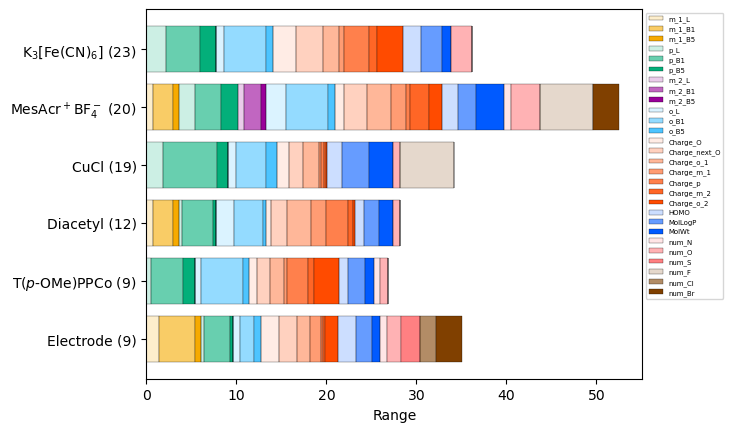

In [19]:
fig = plt.figure()
ax = fig.add_subplot()

y = labels[::-1]

left = [0, 0, 0, 0, 0, 0]

for i in range(28):
    x = df_details.iloc[i].to_list()[::-1]

    ax.barh(y, x, left=left, label=df_details.index[i],
            color=colours[i], edgecolor="k", linewidth=0.2)
    
    left = [a + b for a, b in zip(left, x)]

ax.legend(loc="upper left", fontsize=5, bbox_to_anchor=(1, 1))
ax.set_xlabel("Range")

plt.savefig("range_details.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
conditions.append(["AllPhenols"])

n = len(df1)
li_numbers.append(n)

ss = metrics.metrics_range(df1)
li_range.append(ss[0])
li_details.append(ss[1])

ss[1].to_csv("AllPhenols.csv")

Substrate count: 4665
Range: 234.0981891857267
                    min        max        Q1        Q2        Q3       std  \
m_1_L         -0.289985  13.198278 -0.289985 -0.289985 -0.289985  1.018395   
m_1_B1        -0.677064  14.282021 -0.341846 -0.341846 -0.341846  1.021563   
m_1_B5        -0.284520  13.807443 -0.284520 -0.284520 -0.284520  1.020124   
p_L           -0.757567   5.899003 -0.757567 -0.194029  0.224354  1.003676   
p_B1          -1.147764   7.077354 -1.008748  0.196058  0.613106  1.005386   
p_B5          -0.795090   4.644442 -0.795090 -0.526924  0.585258  1.002269   
m_2_L         -0.306963  10.476212 -0.306963 -0.306963 -0.306963  1.011594   
m_2_B1        -0.728017  12.872240 -0.349180 -0.349180 -0.349180  1.017548   
m_2_B5        -0.311916   8.779397 -0.311916 -0.311916 -0.311916  1.008128   
o_L           -0.833105   6.395698 -0.833105 -0.222564  0.154227  1.004340   
o_B1          -1.270998   5.825188 -1.006215 -0.079475  0.847266  1.003695   
o_B5          -0.

In [21]:
df_result = pd.DataFrame({"Condition": [e[0] for e in conditions],
                          "Number":li_numbers,
                          "Range": li_range})
df_result

,Condition,Number,Range
0,K3FeCN6,23,36.228329
1,MesAcr+BF4-,20,52.504632
2,CuCl,19,34.148565
3,Diacetyl,12,28.231906
4,T(p-OMe)PPCo,9,26.795494
5,Electrode,9,35.016545
6,AllPhenols,4665,234.098189


In [22]:
df_result.to_csv("range.csv", index=False)